# Benchmarks - clustering mixture

**Main considerations when implementing [thing]**

* we want to reuse the already existing hyperpost and likelihood implementations as much as possible

---
## Setup

In [1]:
# Jax configuration
USE_JIT = False
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [2]:
# Standard library imports
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

from functools import partial

In [3]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

In [4]:
# Third party
from jax import jit, vmap
from jax.tree_util import register_pytree_node_class
from jax import numpy as jnp
from jax import lax
from jax.lax import cond

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Local
from Kernax import RBFKernel, AbstractKernel, SEMagmaKernel, DiagKernel, ExpKernel
from MagmaClustPy.utils import preprocess_db
from MagmaClustPy.linalg import map_to_full_matrix_batch, map_to_full_array_batch, compute_mapping, lexicographic_sort
from MagmaClustPy.hyperpost import hyperpost
from MagmaClustPy.initialisation import k_means_init

INFO:2025-11-18 14:56:09,643:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/MagmaClustPy/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
2025-11-18 14:56:09,643 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/MagmaClustPy/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


In [6]:
# Config
key = jax.random.PRNGKey(0)
test_db_size = "medium"
test_db_nb_clust = 4

---
## Data

In [7]:
"""
# Refactoring of the dataset
for size_ in ("huge", "custom"):  # "small", "medium", "large"):  # ,
	for input_ in ("shared", "distinct"):
		for hp_ in ("shared", "distinct"):
			# Load the csv file
			db = pd.read_csv(f"../datasets/K={test_db_nb_clust}/{size_}_{input_}_input_{hp_}_hp.csv")

			# The ID column is formated as "ID{id}-Clust{cluster_nb}"
			# Separate it into two columns: Task_ID and Cluster_ID, containing ints
			db[["Task_ID", "Cluster_ID"]] = db["ID"].str.extract(r'ID(\d+)-Clust(\d+)').astype(int)
			# Make Task_ID unique across clusters by adding NB_IDs * Cluster_ID to Task_ID
			db["Task_ID"] = db["Task_ID"] + db["Task_ID"].nunique() * (db["Cluster_ID"] - 1)
			# Drop Cluster_ID column

			# Drop ID column
			db = db.drop(columns=["ID"])

			# Add an Input_ID column full of "x", and an Output_ID column full of "a"
			db["Input_ID"] = "x"
			db["Output_ID"] = "a"

			# Save the csv file
			db.to_csv(f"../datasets/K={test_db_nb_clust}/{size_}_{input_}_input_{hp_}_hp.csv", index=False)
"""

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/var/folders/zr/lylpr6j91ls4k6rkcfn7dh680000gn/T/ipykernel_29188/1052292119.py:11: SyntaxWarning: invalid escape sequence '\d'
  db[["Task_ID", "Cluster_ID"]] = db["ID"].str.extract(r'ID(\d+)-Clust(\d+)').astype(int)


'\n# Refactoring of the dataset\nfor size_ in ("huge", "custom"):  # "small", "medium", "large"):  # ,\n\tfor input_ in ("shared", "distinct"):\n\t\tfor hp_ in ("shared", "distinct"):\n\t\t\t# Load the csv file\n\t\t\tdb = pd.read_csv(f"../datasets/K={test_db_nb_clust}/{size_}_{input_}_input_{hp_}_hp.csv")\n\n\t\t\t# The ID column is formated as "ID{id}-Clust{cluster_nb}"\n\t\t\t# Separate it into two columns: Task_ID and Cluster_ID, containing ints\n\t\t\tdb[["Task_ID", "Cluster_ID"]] = db["ID"].str.extract(r\'ID(\\d+)-Clust(\\d+)\').astype(int)\n\t\t\t# Make Task_ID unique across clusters by adding NB_IDs * Cluster_ID to Task_ID\n\t\t\tdb["Task_ID"] = db["Task_ID"] + db["Task_ID"].nunique() * (db["Cluster_ID"] - 1)\n\t\t\t# Drop Cluster_ID column\n\n\t\t\t# Drop ID column\n\t\t\tdb = db.drop(columns=["ID"])\n\n\t\t\t# Add an Input_ID column full of "x", and an Output_ID column full of "a"\n\t\t\tdb["Input_ID"] = "x"\n\t\t\tdb["Output_ID"] = "a"\n\n\t\t\t# Save the csv file\n\t\t\tdb.

In [8]:
db = pd.read_csv(f"../datasets/K={test_db_nb_clust}/{test_db_size}_shared_input_shared_hp.csv")
padded_inputs, padded_outputs, mappings, all_inputs = preprocess_db(db)
all_inputs.shape, padded_inputs.shape

((150, 1), (200, 150, 1))

In [9]:
# Retrieve the true cluster of each 150 Task_IDs
true_cluster = jnp.array([])
for clust_id in range(1, test_db_nb_clust+1):
	cluster_task_ids = db[db["Cluster_ID"] == clust_id]["Task_ID"].unique()
	true_cluster = jnp.concatenate([true_cluster, jnp.full(cluster_task_ids.shape, clust_id)])
true_cluster.shape

(200,)

---
## Current implementation

In [10]:
# No current implementation yet

---
## Custom implementation(s)

In [11]:
def plot_outputs_vs_inputs(padded_inputs, padded_outputs, color_by=None, title_suffix="", 
						   post_means=None, post_covs=None, alpha=0.15):
	"""
	Plot outputs vs inputs with optional clustering coloration and posterior distributions.
	
	Parameters
	----------
	padded_inputs : array-like, shape (n_samples, n_points, n_features)
		The input data
	padded_outputs : array-like, shape (n_samples, n_points, n_outputs)
		The output data
	color_by : None, str, or array-like, optional
		How to color the points:
		- None or "sample": color each sample differently
		- array-like: cluster assignments for each sample (shape n_samples)
	title_suffix : str, optional
		Additional text to add to the title (e.g., " (colored by true cluster)")
	post_means : array-like, optional
		Posterior means to plot as lines. Shape should be (n_points,) or (n_clusters, n_points)
		When provided with color_by, each cluster's mean will match the cluster's point color.
	post_covs : array-like, optional
		Posterior covariances to plot as credibility intervals. Shape should be (n_points, n_points) or (n_clusters, n_points, n_points)
	alpha : float, optional
		Transparency for scatter points (default: 0.15)
	"""
	plt.figure(figsize=(8, 6))
	
	if color_by is None or color_by == "sample":
		# Color each sample differently
		for i in range(padded_outputs.shape[0]):
			mask = ~jnp.isnan(padded_outputs[i, :, 0])
			plt.scatter(padded_inputs[i, mask, 0], padded_outputs[i, mask, 0], 
					   label=f"Sample {i+1}", marker=".", alpha=alpha)
		
		# Plot posterior means without cluster coloring
		if post_means is not None:
			if post_means.ndim == 1:
				post_means = post_means[None, :]
			if post_covs is not None and post_covs.ndim == 2:
				post_covs = post_covs[None, :, :]
			
			x_vals = padded_inputs[0, :, 0] if padded_inputs.shape[0] > 0 else jnp.arange(post_means.shape[1])
			
			for i in range(post_means.shape[0]):
				mean = post_means[i]
				if post_covs is not None:
					std = jnp.sqrt(jnp.diag(post_covs[i]))
					plt.fill_between(x_vals, mean - 2*std, mean + 2*std, 
								   alpha=0.2, label=f'95% CI {i+1}' if post_means.shape[0] > 1 else '95% CI')
				label = f'Mean {i+1}' if post_means.shape[0] > 1 else 'Posterior Mean'
				plt.plot(x_vals, mean, linewidth=2, label=label)
	else:
		# Color by cluster assignments
		cluster_ids = jnp.unique(color_by)
		n_clusters = len(cluster_ids)
		colors = plt.cm.get_cmap('tab10', int(n_clusters) + 1)
		
		# Plot points for each cluster
		for clust_id in cluster_ids:
			cluster_task_indices = jnp.where(color_by == clust_id)[0]
			color = colors(int(clust_id))
			
			for sample_idx in cluster_task_indices:
				mask = ~jnp.isnan(padded_outputs[sample_idx, :, 0])
				plt.scatter(padded_inputs[sample_idx, mask, 0], 
						  padded_outputs[sample_idx, mask, 0], 
						  color=color, marker=".", alpha=alpha)
		
		# Plot posterior means with matching cluster colors
		if post_means is not None:
			if post_means.ndim == 1:
				post_means = post_means[None, :]
			if post_covs is not None and post_covs.ndim == 2:
				post_covs = post_covs[None, :, :]
			
			x_vals = padded_inputs[0, :, 0] if padded_inputs.shape[0] > 0 else jnp.arange(post_means.shape[1])
			
			# Match each post_mean to its cluster
			for i, clust_id in enumerate(cluster_ids):
				if i >= post_means.shape[0]:
					break
				
				mean = post_means[i]
				color = colors(int(clust_id))
				
				# Plot credibility interval if covariance is provided
				if post_covs is not None:
					std = jnp.sqrt(jnp.diag(post_covs[i]))
					plt.fill_between(x_vals, mean - 2*std, mean + 2*std, 
								   color=color, alpha=0.2, label=f'95% CI Cluster {int(clust_id)}')
				
				# Plot mean as a line
				plt.plot(x_vals, mean, linewidth=2, color=color, 
						label=f'Mean Cluster {int(clust_id)}')
	
	plt.title(f"Outputs vs Inputs{title_suffix}")
	plt.xlabel("Input")
	plt.ylabel("Output")
	plt.grid()
	plt.show()

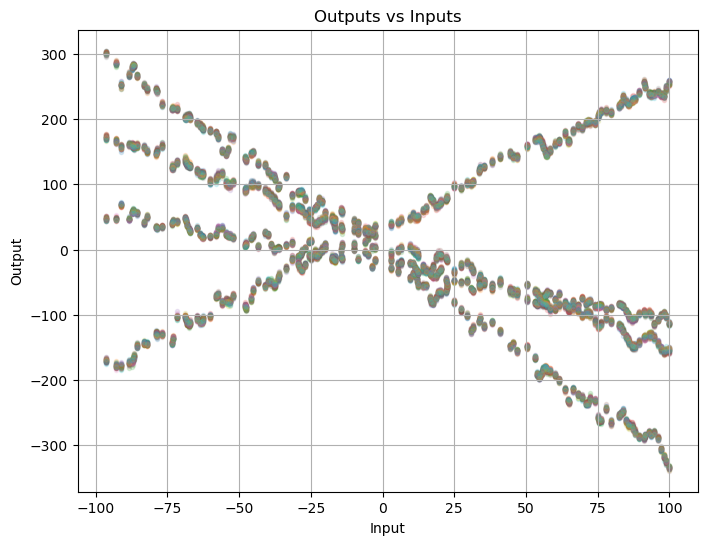

In [12]:
# display the data
# x axis = input
# y axis = output
# each sample is plotted as points of the same color

plot_outputs_vs_inputs(padded_inputs, padded_outputs)

/var/folders/zr/lylpr6j91ls4k6rkcfn7dh680000gn/T/ipykernel_29188/2522640122.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', int(n_clusters) + 1)


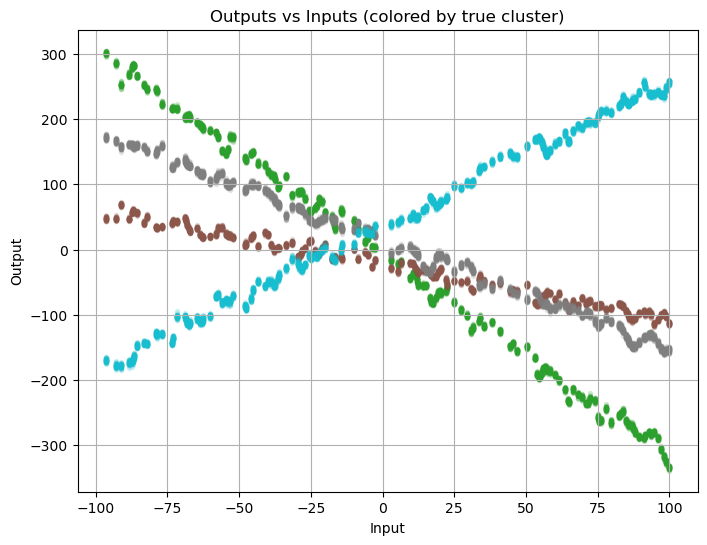

In [13]:
# Same plot, but color the points according to their true cluster
plot_outputs_vs_inputs(padded_inputs, padded_outputs, color_by=true_cluster, title_suffix=" (colored by true cluster)")

In [14]:
# Compute initial mixture using k-means
init_mixture = k_means_init(padded_outputs, k=test_db_nb_clust, distinct_hp=False)
init_mixture.shape

(4, 200)

/var/folders/zr/lylpr6j91ls4k6rkcfn7dh680000gn/T/ipykernel_29188/2522640122.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', int(n_clusters) + 1)


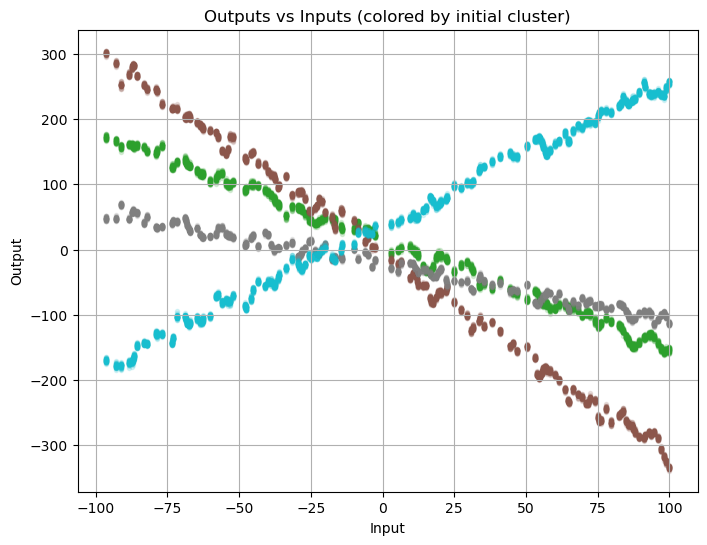

In [15]:
# Same plot, but color the points according to their initial cluster
plot_outputs_vs_inputs(padded_inputs, padded_outputs, color_by=jnp.argmax(init_mixture, axis=0) + 1, title_suffix=" (colored by initial cluster)")

In [16]:
mean_kern = RBFKernel(length_scale=jnp.array(.3), variance=jnp.array(1.))
task_kern = RBFKernel(length_scale=jnp.array(.6), variance=jnp.array(1.))

In [17]:
shared_input = len(padded_inputs[0]) == len(all_inputs) and not jnp.any(jnp.isnan(padded_inputs))
shared_hp = not task_kern.has_distinct_hyperparameters(padded_inputs.shape[0])

In [18]:
init_mixture.shape

(4, 200)

In [19]:
post_means, post_covs = vmap(hyperpost, in_axes=(None, None, None, None, None, None, None, None, None, 0))(
	padded_inputs, padded_outputs, mappings, all_inputs,
	jnp.array(0.), mean_kern, task_kern,
	shared_input, shared_hp, init_mixture)
post_means.shape, post_covs.shape

((4, 150), (4, 150, 150))

/var/folders/zr/lylpr6j91ls4k6rkcfn7dh680000gn/T/ipykernel_29188/2522640122.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', int(n_clusters) + 1)


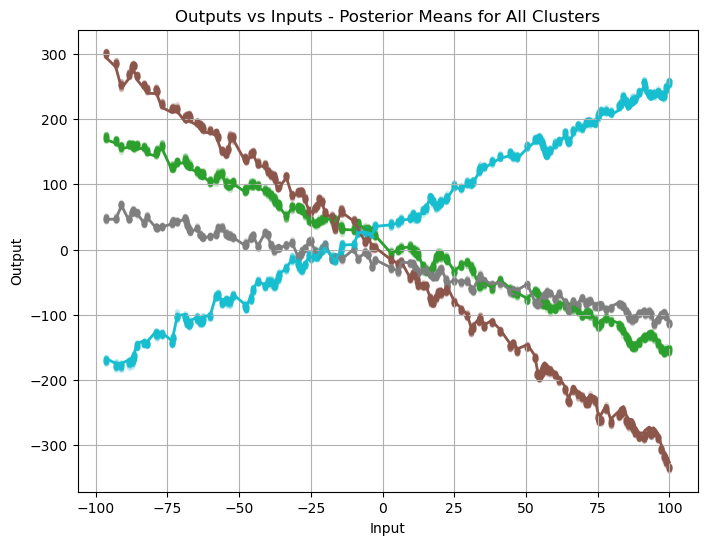

In [20]:
# Plot all posterior means on one graph with matching cluster colors
cluster_assignments = jnp.argmax(init_mixture, axis=0) + 1

plot_outputs_vs_inputs(
	padded_inputs,
	padded_outputs,
	color_by=cluster_assignments,
	title_suffix=" - Posterior Means for All Clusters",
	post_means=post_means,
	post_covs=post_covs,
	alpha=0.15
)

In [21]:
np.asarray(init_mixture)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.,

---
## Comparison

---
## Conclusion

---